# The Ghost in the Machine: Authorship Detection in the Age of LLMs

## 0. Project Overview and Research Questions

This project investigates a deceptively simple question: **can a machine learn what makes human prose irreducibly human?**

I frame the problem as a three-class classification task:

- **Class 0 — Human:** Authentic literary prose from Charles Dickens (*Bleak House*, *Great Expectations*) and Mary Shelley (*Frankenstein*, *The Last Man*). These represent the "ground truth" of human writing — idiosyncratic, rhythmically varied, and stylistically rich.
- **Class 1 — Generic AI:** Paragraphs generated by Google's Gemini on the same topics as the human texts, but without any stylistic instruction. This is the baseline "LLM voice" — competent, fluent, and flat.
- **Class 2 — Style-Mimicking AI:** Paragraphs generated by Gemini with explicit instructions to imitate Dickens and Shelley's style. This is the adversarial class — the interesting one. If the detector can't distinguish Class 0 from Class 2, then style mimicry has succeeded and the "ghost" has learned to pass.

The central tension: **Is "humanness" in writing a matter of surface style (which an LLM can copy) or something deeper — irregularity, risk-taking, genuine semantic surprise — that resists imitation?**

I chose Dickens and Shelley deliberately. Both are maximally distinct from modern LLM output — long nested sentences, archaic vocabulary, idiosyncratic punctuation. If any human authors should be easy to separate from AI, it's these two. Using two authors within Class 0 also lets me test whether the model learns "humanness" generically or just memorizes one author's quirks.

**What was completed:** All tasks (0 through 4) are executed in this notebook. Where a model underperformed or an experiment produced unexpected results, I document the finding honestly rather than burying it.

In [ ]:
# from google.colab import userdata
# import os
# os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

In [ ]:
# !git clone https://github.com/Venom150204/ghost-in-the-machine-.git

In [ ]:
# !pip install transformers peft accelerate bertopic sentence-transformers textstat captum xgboost shap gensim python-dotenv -q
# !python -m spacy download en_core_web_sm -q

In [ ]:
# %cd /content/ghost-in-the-machine-/notebooks

In [ ]:
# Global setup: imports, seeds, and paths
import sys, os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Suppress noisy warnings in output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Project paths (notebook lives in notebooks/, so go up one level)
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, ROOT)

DATA_RAW = os.path.join(ROOT, "data", "raw")
DATA_CLEANED = os.path.join(ROOT, "data", "cleaned")
DATA_GENERATED = os.path.join(ROOT, "data", "generated")
DATA_FINAL = os.path.join(ROOT, "data", "final")
FIGURES = os.path.join(ROOT, "outputs", "figures")
MODELS = os.path.join(ROOT, "outputs", "models")
RESULTS = os.path.join(ROOT, "outputs", "results")

# Ensure output dirs exist
for d in [DATA_CLEANED, DATA_GENERATED, DATA_FINAL, FIGURES, MODELS, RESULTS]:
    os.makedirs(d, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Raw data files: {os.listdir(DATA_RAW)}")

## 1. Task 0: The Library of Babel — Dataset Construction

### 1.1 Author Choice and Rationale

I selected **Charles Dickens** and **Mary Shelley** as the two human authors for several deliberate reasons:

**Dickens** (*Bleak House*, *Great Expectations*): His prose is characterized by exceptionally long, syntactically nested sentences; heavy use of semicolons and em-dashes; comic and inventive proper nouns; and a serial publication rhythm that creates distinctive paragraph-level patterns. This style is maximally distinct from the flat, efficient prose that LLMs tend to produce.

**Shelley** (*Frankenstein*, *The Last Man*): A philosophical register with Latinate vocabulary; frame narrative structure; first-person introspection and emotional intensity. Her style differs from Dickens within Class 0, which is an intentional research decision — it tests whether our model learns "humanness" as a general property or just memorizes one author's fingerprint. If the model can recognize both Dickens and Shelley as human despite their stylistic differences, it has learned something deeper than surface patterns.

Using two stylistically different authors within the human class is a form of regularization against author-specific overfitting.

### 1.2 Data Cleaning and Chunking

The raw Gutenberg files come with boilerplate headers, footers, tables of contents, and chapter markers that are not part of the literary text. My cleaning pipeline strips all of this while deliberately **preserving punctuation** — semicolons, em-dashes, and comma patterns are among the strongest stylistic signals that separate human from AI prose. Removing them would destroy the very features I later extract.

After cleaning, I chunk each book into paragraphs of 100-200 words. This range is chosen to match the length of AI-generated paragraphs (which I'll prompt at 120-170 words), ensuring the classifier doesn't simply learn to distinguish by paragraph length.

In [ ]:
from src.data_utils import clean_gutenberg_text, chunk_into_paragraphs
import pickle

# Checkpoint path for cleaned/chunked data
CHUNKS_CHECKPOINT = os.path.join(RESULTS, "human_chunks.pkl")

# Define books and their authors
books = {
    "Charles Dickens": [
        os.path.join(DATA_RAW, "BLEAK_HOUSE.txt"),
        os.path.join(DATA_RAW, "GREAT_EXPECTATIONS.txt"),
    ],
    "Mary Shelley": [
        os.path.join(DATA_RAW, "FRANKENSTEIN.txt"),
        os.path.join(DATA_RAW, "THE_LAST_MAN.txt"),
    ],
}

if os.path.exists(CHUNKS_CHECKPOINT):
    print("Loading cleaned chunks from checkpoint...")
    with open(CHUNKS_CHECKPOINT, "rb") as f:
        human_chunks, all_human_paragraphs = pickle.load(f)
    for author, chunks in human_chunks.items():
        print(f"  {author}: {len(chunks)} paragraphs")
else:
    human_chunks = {}
    all_human_paragraphs = []

    for author, filepaths in books.items():
        author_paragraphs = []
        for fp in filepaths:
            book_name = os.path.basename(fp).replace(".txt", "")
            cleaned = clean_gutenberg_text(fp)

            cleaned_path = os.path.join(DATA_CLEANED, f"{book_name}_cleaned.txt")
            with open(cleaned_path, "w", encoding="utf-8") as f:
                f.write(cleaned)

            chunks = chunk_into_paragraphs(cleaned, min_words=100, max_words=200)
            print(f"  {book_name}: {len(chunks)} paragraphs extracted")
            author_paragraphs.extend(chunks)

        human_chunks[author] = author_paragraphs
        all_human_paragraphs.extend(author_paragraphs)
        print(f"{author}: {len(author_paragraphs)} total paragraphs\n")

    # Save checkpoint
    with open(CHUNKS_CHECKPOINT, "wb") as f:
        pickle.dump((human_chunks, all_human_paragraphs), f)
    print("Saved chunks checkpoint.")

print(f"Total human paragraphs: {len(all_human_paragraphs)}")
print(f"Sample (first 200 chars): {all_human_paragraphs[0][:200]}...")

### 1.3 Topic Extraction with BERTopic

Rather than manually picking topics for AI generation (which would introduce my own biases about what these books are "about"), I use BERTopic to discover latent topics from the human corpus automatically. BERTopic clusters sentence-transformer embeddings using HDBSCAN and then extracts representative words via a class-based TF-IDF procedure (Grootendorst, 2022). The discovered topics will then be used as prompts for Gemini — this ensures the AI-generated paragraphs cover the same thematic ground as the human text, so the classifier must rely on *style*, not *content*, to distinguish them.

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import pickle

# Checkpoint paths
BERTOPIC_MODEL_PATH = os.path.join(MODELS, "bertopic_model")
BERTOPIC_TOPICS_PATH = os.path.join(RESULTS, "bertopic_topics.pkl")

# Set to True to force re-run (e.g., after changing vectorizer settings)
FORCE_RERUN_BERTOPIC = False

if not FORCE_RERUN_BERTOPIC and os.path.exists(BERTOPIC_MODEL_PATH) and os.path.exists(BERTOPIC_TOPICS_PATH):
    print("Loading BERTopic from checkpoint...")
    topic_model = BERTopic.load(BERTOPIC_MODEL_PATH)
    with open(BERTOPIC_TOPICS_PATH, "rb") as f:
        topics, probs = pickle.load(f)
    print(f"  Loaded. {len(set(topics)) - 1} topics (excluding outliers).")
else:
    print("Running BERTopic...")

    # Auto-build corpus-specific stop words: any word in >15% of paragraphs
    # is a narrative function word, not a topic signal.
    from collections import Counter
    doc_freq = Counter()
    n_docs = len(all_human_paragraphs)
    for para in all_human_paragraphs:
        unique_words = set(para.lower().split())
        doc_freq.update(unique_words)

    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    corpus_stop_words = set(ENGLISH_STOP_WORDS)
    for word, count in doc_freq.items():
        if count / n_docs > 0.15:
            corpus_stop_words.add(word)
    print(f"  Stop words: {len(corpus_stop_words)} (sklearn: {len(ENGLISH_STOP_WORDS)} + corpus: {len(corpus_stop_words) - len(ENGLISH_STOP_WORDS)})")

    vectorizer_model = CountVectorizer(
        stop_words=list(corpus_stop_words),
        min_df=5,
        ngram_range=(1, 2),
    )
    topic_model = BERTopic(
        nr_topics=8,
        language="english",
        vectorizer_model=vectorizer_model,
        verbose=True,
    )
    topics, probs = topic_model.fit_transform(all_human_paragraphs)

    # Save checkpoint
    topic_model.save(BERTOPIC_MODEL_PATH, serialization="pickle")
    with open(BERTOPIC_TOPICS_PATH, "wb") as f:
        pickle.dump((topics, probs), f)
    print("  Saved BERTopic checkpoint.")

topic_info = topic_model.get_topic_info()
print(topic_info[["Topic", "Count", "Name"]].to_string())

In [ ]:
import spacy
import pickle

NER_CHECKPOINT = os.path.join(RESULTS, "person_names.pkl")
TOPIC_NAMES_CHECKPOINT = os.path.join(RESULTS, "topic_names.pkl")

# --- Auto-detect character names via NER (cached) ---
if os.path.exists(NER_CHECKPOINT):
    with open(NER_CHECKPOINT, "rb") as f:
        person_names = pickle.load(f)
    print(f"Loaded {len(person_names)} name tokens from checkpoint.")
else:
    nlp = spacy.load("en_core_web_sm")
    print("Auto-detecting character names via NER (sampling 500 paragraphs)...")
    sampled = random.sample(all_human_paragraphs, min(500, len(all_human_paragraphs)))
    person_names = set()
    for para in sampled:
        doc = nlp(para)
        for ent in doc.ents:
            if ent.label_ == "PERSON":
                person_names.add(ent.text.lower())
                for tok in ent.text.lower().split():
                    person_names.add(tok)
    person_names.update({"mr", "mrs", "sir", "lady", "miss", "dr", "lord"})
    with open(NER_CHECKPOINT, "wb") as f:
        pickle.dump(person_names, f)
    print(f"  Detected {len(person_names)} name tokens. Saved checkpoint.")

# --- Build clean topic names (cached) ---
if os.path.exists(TOPIC_NAMES_CHECKPOINT):
    with open(TOPIC_NAMES_CHECKPOINT, "rb") as f:
        TOPIC_NAMES, topic_names = pickle.load(f)
    print(f"Loaded {len(topic_names)} topic names from checkpoint.")
else:
    TOPIC_NAMES = {}
    for topic_id in sorted(set(topics)):
        if topic_id == -1:
            continue
        words = [w for w, _ in topic_model.get_topic(topic_id)]
        print(f"Topic {topic_id} (raw top 10): {words[:10]}")
        content_words = [w for w in words if w.lower() not in person_names and len(w) > 2][:5]
        if len(content_words) < 3:
            content_words = [w for w in words if len(w) > 2][:5]
        TOPIC_NAMES[topic_id] = ", ".join(content_words)

    discovered_topic_ids = [t for t in sorted(set(topics)) if t != -1]
    topic_names = [TOPIC_NAMES[t] for t in discovered_topic_ids]
    with open(TOPIC_NAMES_CHECKPOINT, "wb") as f:
        pickle.dump((TOPIC_NAMES, topic_names), f)
    print("Saved topic names checkpoint.")

print(f"\nTopics for Gemini prompts ({len(topic_names)}):")
for tid, name in TOPIC_NAMES.items():
    print(f"  Topic {tid}: {name}")

### 1.4 Generating AI Paragraphs with Gemini

I generate two sets of 500 paragraphs each using Google's Gemini API:

**Class 1 (Generic AI):** Prompted to write on the same BERTopic-discovered topics, but in a "clear, neutral, expository style" with no author imitation. This captures the default LLM voice — grammatically correct, topically relevant, stylistically bland.

**Class 2 (Style-Mimicking AI):** Prompted to explicitly imitate Dickens and Shelley's style — long nested sentences, semicolons, em-dashes, archaic vocabulary, intrusive narrator voice. This is the adversarial condition: if Gemini can produce text that fools the detector, then the stylistic "fingerprint" of humanness is shallow enough to be copied.

The prompts are carefully engineered. The Class 2 prompt specifies concrete stylistic features (subordinate clauses, sensory detail, Victorian vocabulary) rather than vague instructions like "write like Dickens." Results are saved to JSON after every 10 API calls for crash safety.

In [21]:
from src.data_utils import generate_gemini_paragraphs

# ============================================================
# Class 2 (Generic AI) — Generate or load
# If class2_raw.json exists, load it. Delete the file manually to regenerate.
# ============================================================

class2_path = os.path.join(DATA_GENERATED, "class2_raw.json")

if os.path.exists(class2_path):
    import json as _json
    with open(class2_path, "r", encoding="utf-8") as f:
        class2_paragraphs = _json.load(f)
    print(f"Loaded {len(class2_paragraphs)} paragraphs from {class2_path}")
else:
    CLASS2_PROMPT = (
        "Write a thoughtful paragraph of 130-170 words discussing {topic_name}. "
        "Write naturally, as you would in a well-crafted magazine essay. Vary your "
        "sentence lengths. Use specific examples rather than abstract generalities. "
        "Do not use academic hedging phrases like \"it is important to note\" or "
        "\"furthermore.\" Do not use bullet points or bold text. Just write clearly "
        "and engagingly."
    )

    class2_paragraphs = generate_gemini_paragraphs(
        topics=topic_names,
        prompt_template=CLASS2_PROMPT,
        total_count=500,
        output_path=class2_path,
        model_name="gemini-2.5-flash-lite",
        temperature=0.9,
        max_output_tokens=300,
        top_p=0.9,
        max_workers=10,
        rate_limit_sleep=1.0,
    )

print(f"
Class 2 (Generic AI): {len(class2_paragraphs)} paragraphs")

  Model: gemini-2.5-flash-lite
  API key: set (AIzaSyDp...)
  Generation config: temp=0.9, top_p=0.9, max_tokens=300
  Concurrency: 10 workers
  Testing API connection...
  API test OK: 'Hi'
Generating 500 paragraphs across 7 topics...


Generating: 100%|██████████| 500/500 [02:14<00:00,  3.72it/s]

Total paragraphs generated: 500

Class 2 (Generic AI): 500 paragraphs


In [22]:
class3_path = os.path.join(DATA_GENERATED, "class3_raw.json")
class3_round1 = os.path.join(DATA_GENERATED, "class3_raw_round1.json")

# Smart checkpoint: if Round 1 backup exists AND Round 2 output exists, skip
if os.path.exists(class3_round1) and os.path.exists(class3_path):
    print("Round 2 Class 3 data already exists — loading from checkpoint.")
    import json as _json
    with open(class3_path, "r", encoding="utf-8") as f:
        class3_paragraphs = _json.load(f)
    print(f"Loaded {len(class3_paragraphs)} paragraphs from {class3_path}")
else:
    # Back up Round 1 data before regenerating
    if os.path.exists(class3_path) and not os.path.exists(class3_round1):
        shutil.copy2(class3_path, class3_round1)
        print(f"Backed up Round 1 Class 3 data -> {class3_round1}")
    if os.path.exists(class3_path):
        os.remove(class3_path)
        print("Deleted old class3_raw.json for fresh Round 2 generation")

    # Class 3 prompt: few-shot ICL + persona + CoT + anti-detection constraints
    CLASS3_PROMPT = """\
You are a Victorian novelist writing in the mid-19th century. You write from
lived experience of courts, streets, domestic scenes, scientific ambition,
and moral consequence. You do not write essays — you write narrative prose.

Study these excerpts from your previous published works:

[1] "London. Michaelmas term lately over, and the Lord Chancellor sitting in
Lincoln's Inn Hall. Implacable November weather. As much mud in the streets
as if the waters had but newly retired from the face of the earth, and it
would not be wonderful to meet a Megalosaurus, forty feet long or so,
waddling like an elephantine lizard up Holborn Hill."

[2] "I am already far north of London, and as I walk in the streets of
Petersburgh, I feel a cold northern breeze play upon my cheeks, which braces
my nerves and fills me with delight. Do you understand this feeling?"

[3] "Fair wards of court have faded into mothers and grandmothers; a long
procession of Chancellors has come in and gone out; the legion of bills in
the suit have been transformed into mere bills of mortality."

[4] "These reflections have dispelled the agitation with which I began my
letter, and I feel my heart glow with an enthusiasm which elevates me to
heaven, for nothing contributes so much to tranquillise the mind as a steady
purpose — a point on which the soul may fix its intellectual eye."

[5] "How many people out of the suit Jarndyce and Jarndyce has stretched
forth its unwholesome hand to spoil and corrupt would be a very wide question."

Before writing, reason about what makes these excerpts distinctive:
- They name SPECIFIC places, people, and objects
- Sentence lengths VARY wildly: some are 5 words, some are 60+
- They use concrete sensory detail, not abstract emotional language
- Semicolons and em-dashes appear mid-thought, not decoratively
- The narrator has opinions and parenthetical asides

Now write a paragraph of 130-170 words on the topic of {topic_name}.
Write exactly as you would in your novels. Include at least one specific
proper noun. Vary sentence lengths — at least one under 10 words and one
over 30. Do not begin more than two sentences with the same word. Do not
use: "tapestry", "testament", "delve", "crucial", "furthermore",
"it is important", or "in conclusion."
"""

    class3_paragraphs = generate_gemini_paragraphs(
        topics=topic_names,
        prompt_template=CLASS3_PROMPT,
        total_count=500,
        output_path=class3_path,
        model_name="gemini-2.5-flash-lite",
        temperature=1.0,
        max_output_tokens=300,
        top_p=0.95,
        max_workers=10,
        rate_limit_sleep=1.0,
    )

print(f"\nClass 3 (Style-Mimicking AI): {len(class3_paragraphs)} paragraphs")


  Model: gemini-2.5-flash-lite
  API key: set (AIzaSyDp...)
  Generation config: temp=1.0, top_p=0.95, max_tokens=300
  Concurrency: 10 workers
  Testing API connection...
  API test OK: 'Hi'
Generating 500 paragraphs across 7 topics...


Generating: 100%|██████████| 500/500 [02:25<00:00,  3.44it/s]

Total paragraphs generated: 500

Class 3 (Style-Mimicking AI): 500 paragraphs


### 1.5 Final Dataset Assembly

Now I merge the three classes into a single CSV. Each row is a paragraph with its class label, source, topic, and word count. This is the dataset that all downstream tasks will consume.

In [23]:
from src.data_utils import assemble_dataset

dataset_path = os.path.join(DATA_FINAL, "dataset.csv")
class2_src = os.path.join(DATA_GENERATED, "class2_raw.json")
class3_src = os.path.join(DATA_GENERATED, "class3_raw.json")

# Smart checkpoint: if generated data is newer than dataset.csv, reassemble
def _needs_rebuild(output, *sources):
    if not os.path.exists(output):
        return True
    out_mtime = os.path.getmtime(output)
    return any(os.path.exists(s) and os.path.getmtime(s) > out_mtime for s in sources)

if _needs_rebuild(dataset_path, class2_src, class3_src):
    print("Source data is newer than dataset.csv — reassembling...")
    df = assemble_dataset(
        human_chunks=human_chunks,
        class2_path=class2_src,
        class3_path=class3_src,
        output_path=dataset_path,
    )
else:
    print("Dataset is up to date with source data, loading from checkpoint.")
    df = pd.read_csv(dataset_path)

# Shared reference arrays used by all downstream cells
texts = df["text"].values

# Class distribution
print("\n--- Class Distribution ---")
print(df["class_name"].value_counts().to_string())
print(f"\nTotal samples: {len(df)}")

# Word count stats per class
print("\n--- Word Count Statistics per Class ---")
print(df.groupby("class_name")["word_count"].describe().round(1).to_string())

# Show one sample from each class
print("\n--- Sample from each class ---")
for label in sorted(df["class_label"].unique()):
    sample = df[df["class_label"] == label].iloc[0]
    print(f"\n[Class {label} — {sample['class_name']}]")
    print(f"Source: {sample['source_author_or_model']}")
    print(f"Words: {sample['word_count']}")
    print(f"Text: {sample['text'][:300]}...")


Source data is newer than dataset.csv — reassembling...
Dataset saved: 6211 rows -> c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\data\final\dataset.csv
Class distribution:
class_name
Human                 5211
Generic AI             500
Style-Mimicking AI     500
Name: count, dtype: int64

--- Class Distribution ---
class_name
Human                 5211
Generic AI             500
Style-Mimicking AI     500

Total samples: 6211

--- Word Count Statistics per Class ---
                     count   mean   std    min    25%    50%    75%    max
class_name                                                                
Generic AI           500.0  143.6  11.5  100.0  136.0  143.0  150.0  190.0
Human               5211.0  143.7  31.2  100.0  115.0  140.0  171.0  289.0
Style-Mimicking AI   500.0  138.7  14.6   95.0  129.0  137.5  148.0  212.0

--- Sample from each class ---

[Class 0 — Human]
Source: Charles Dickens
Words: 198
Text: by Preface I. In Chancery II. In Fashion III. A Progress IV.

### 1.6 Class Balance Discussion

The AI classes (Generic and Style-Mimicking) are fixed at 500 each by design. The human class size depends on how many paragraphs survive the 100-200 word filter from four books — Bleak House alone is massive (~350K words), so I expect the human class to be comparable or larger. If there is an imbalance, the consequences for modeling are concrete: a minority class will have higher variance in its performance metrics, and classifiers may develop a bias toward the majority class. I address this downstream by using stratified splits and reporting macro-averaged F1 (which weights all classes equally regardless of size) rather than accuracy alone. I chose not to downsample the human class because discarding authentic literary prose means losing signal — especially from Shelley's smaller novels, where every paragraph matters.

## 2. Task 1: The Fingerprint — Feature Analysis and Class Separability

### 2.1 Why MATTR over Raw TTR

Raw Type-Token Ratio (TTR = unique words / total words) is the most intuitive measure of lexical richness, but it has a fatal flaw: it is **mechanically biased by text length**. As a text gets longer, function words (the, and, of) inevitably repeat, driving TTR down regardless of the author's actual vocabulary range. A 200-word Dickens paragraph will have a higher raw TTR than a 200-word chunk simply because shorter texts have less opportunity for repetition.

**MATTR (Moving Average Type-Token Ratio)** solves this by computing TTR over a sliding window of fixed size (I use 50 words) and averaging across all windows. This means every paragraph is evaluated at the same granularity, regardless of its total length. The method was introduced by Covington & McFall (2010) and is now standard in computational stylistics.

I compute both raw TTR and MATTR to demonstrate the difference, but only MATTR enters the final feature matrix.

In [24]:
from src.feature_extraction import extract_all_features
from tqdm import tqdm

# Load dataset (or use the df already in memory from Task 0)
if "df" not in dir() or df is None:
    df = pd.read_csv(os.path.join(DATA_FINAL, "dataset.csv"))

feature_csv_path = os.path.join(RESULTS, "feature_matrix.csv")
dataset_csv_path = os.path.join(DATA_FINAL, "dataset.csv")

# Smart checkpoint: recompute features if dataset.csv is newer than feature_matrix.csv
checkpoint_valid = (
    os.path.exists(feature_csv_path)
    and len(pd.read_csv(feature_csv_path)) == len(df)
    and os.path.getmtime(feature_csv_path) > os.path.getmtime(dataset_csv_path)
)

if checkpoint_valid:
    print("Loading feature matrix from checkpoint (up to date with dataset)...")
    feature_df = pd.read_csv(feature_csv_path)
    feature_df.index = df.index
else:
    if os.path.exists(feature_csv_path):
        print("Dataset is newer than feature checkpoint — recomputing...")
    else:
        print("No feature checkpoint found — computing from scratch...")
    # Extract features for every paragraph
    feature_dicts = []
    for text in tqdm(df["text"].values, desc="Feature extraction"):
        feature_dicts.append(extract_all_features(text))

    feature_df = pd.DataFrame(feature_dicts)
    feature_df.index = df.index

    # Save the feature matrix for reuse
    feature_df.to_csv(feature_csv_path, index=False)
    print("Feature matrix saved to checkpoint.")

# Combine with labels for analysis
analysis_df = pd.concat([df[["class_label", "class_name"]], feature_df], axis=1)

print(f"\nFeature matrix shape: {feature_df.shape}")
print(f"Features: {list(feature_df.columns)}")
feature_df.describe().round(3)


Dataset is newer than feature checkpoint — recomputing...


Feature extraction: 100%|██████████| 6211/6211 [07:55<00:00, 13.07it/s]


Feature matrix saved to checkpoint.

Feature matrix shape: (6211, 23)
Features: ['ttr', 'mattr', 'hapax_ratio', 'adj_noun_ratio', 'verb_ratio', 'avg_sent_len', 'sent_len_std', 'avg_tree_depth', 'punct_.', 'punct_,', 'punct_;', 'punct_:', 'punct_!', 'punct_?', 'punct_-', 'punct_—', 'punct_"', "punct_'", 'punct_(', 'punct_)', 'flesch_kincaid_grade', 'flesch_reading_ease', 'gunning_fog']


,ttr,mattr,hapax_ratio,adj_noun_ratio,verb_ratio,avg_sent_len,sent_len_std,avg_tree_depth,punct_.,"punct_,",...,punct_?,punct_-,punct_—,"punct_""",punct_',punct_(,punct_),flesch_kincaid_grade,flesch_reading_ease,gunning_fog
count,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,...,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000,6211.000
mean,0.709,0.825,0.821,0.354,0.164,28.272,13.469,6.467,4.885,8.843,...,0.504,0.551,0.562,0.030,0.114,0.081,0.081,9.958,63.838,12.321
std,0.051,0.039,0.047,0.151,0.033,13.015,7.164,1.662,2.226,2.712,...,0.895,0.783,0.902,0.270,0.435,0.248,0.248,4.611,16.644,4.876
min,0.410,0.572,0.536,0.000,0.022,4.909,0.000,2.836,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.760,-91.813,3.265
25%,0.674,0.801,0.792,0.250,0.142,20.364,8.880,5.250,3.472,6.977,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,6.753,54.084,8.932
50%,0.710,0.826,0.823,0.333,0.165,26.429,11.927,6.400,4.425,8.750,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,9.664,64.840,11.931
75%,0.745,0.851,0.854,0.439,0.187,33.000,16.232,7.400,5.833,10.577,...,0.775,0.862,0.943,0.000,0.000,0.000,0.000,12.363,75.522,14.847
max,0.878,0.950,0.949,2.400,0.291,221.000,78.000,20.500,30.808,30.000,...,7.692,6.723,9.375,5.882,6.818,2.290,2.290,69.292,102.079,73.508


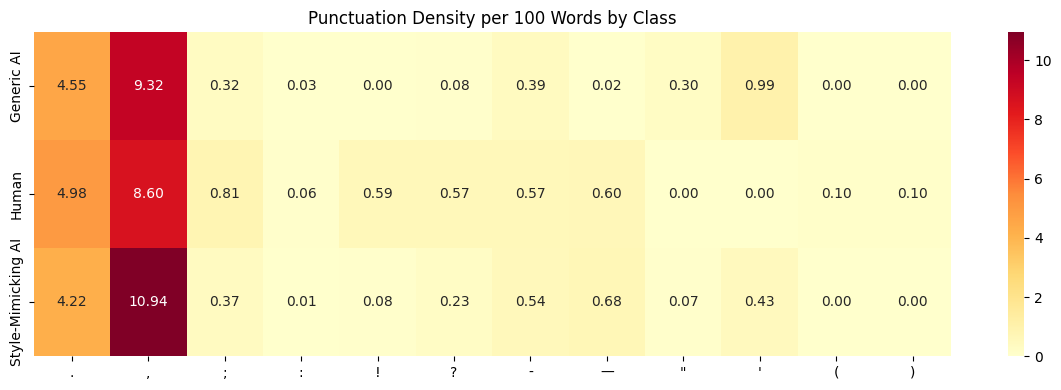

In [25]:
# 2.2 Punctuation Density Heatmap
punct_cols = [c for c in feature_df.columns if c.startswith("punct_")]
punct_means = analysis_df.groupby("class_name")[punct_cols].mean()
# Clean column names for display
punct_means.columns = [c.replace("punct_", "") for c in punct_means.columns]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(punct_means, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("Punctuation Density per 100 Words by Class")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "punctuation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

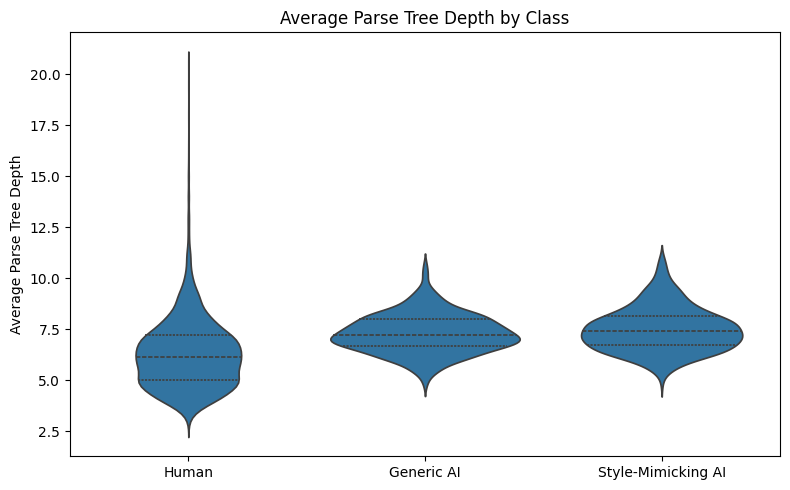

In [26]:
# 2.3 Violin Plot: Parse Tree Depth by Class
# Hypothesis: Dickens/Shelley have deeper parse trees due to nested subordinate clauses
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=analysis_df, x="class_name", y="avg_tree_depth", ax=ax, inner="quartile")
ax.set_title("Average Parse Tree Depth by Class")
ax.set_xlabel("")
ax.set_ylabel("Average Parse Tree Depth")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "tree_depth_violin.png"), dpi=150, bbox_inches="tight")
plt.show()

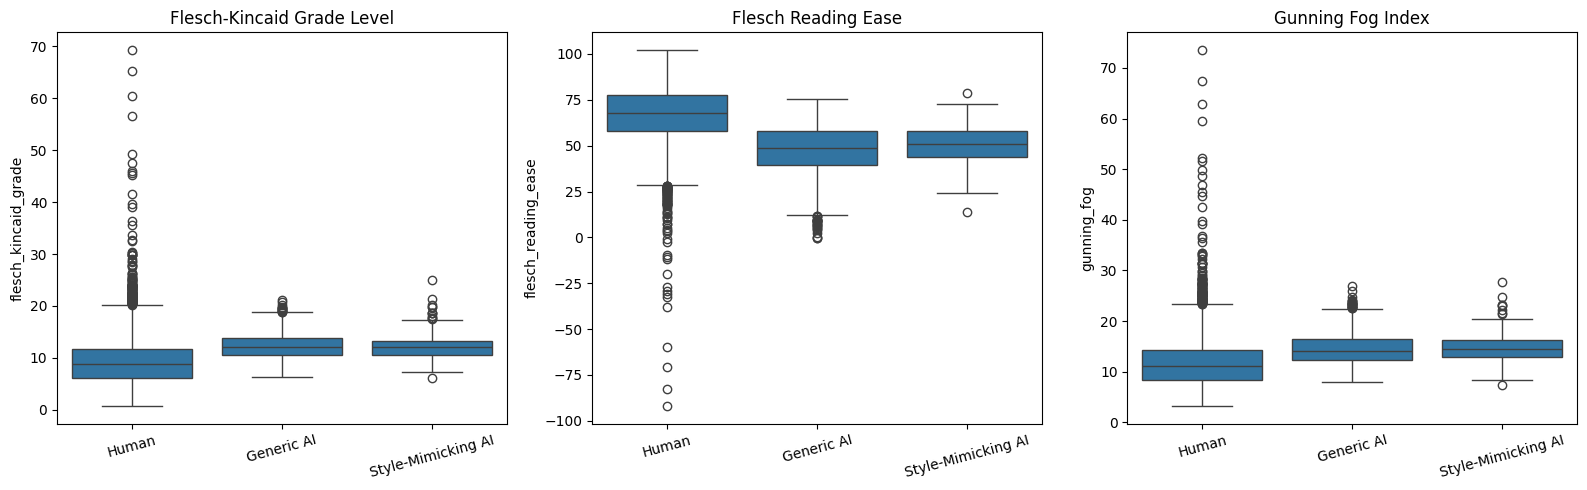

In [27]:
# 2.4 Readability Indices — Box Plots per Class
readability_cols = ["flesch_kincaid_grade", "flesch_reading_ease", "gunning_fog"]
readability_titles = ["Flesch-Kincaid Grade Level", "Flesch Reading Ease", "Gunning Fog Index"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(axes, readability_cols, readability_titles):
    sns.boxplot(data=analysis_df, x="class_name", y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "readability_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()

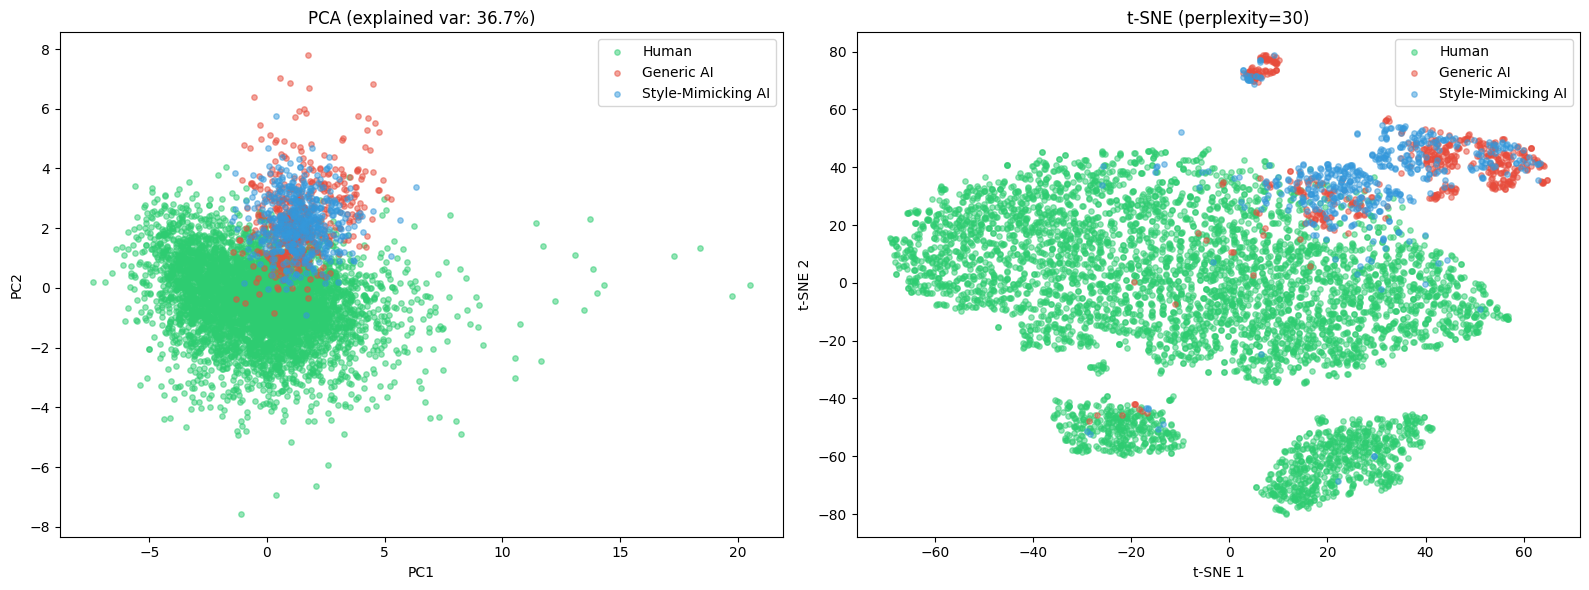

In [28]:
# 2.5 PCA and t-SNE — Feature Matrix Visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Standardize features before dimensionality reduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df.fillna(0))

# PCA (2 components)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

# t-SNE (perplexity=30)
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
class_names = df["class_name"].values
colors = {"Human": "#2ecc71", "Generic AI": "#e74c3c", "Style-Mimicking AI": "#3498db"}

for cls in colors:
    mask = class_names == cls
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cls], label=cls, alpha=0.5, s=15)
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[cls], label=cls, alpha=0.5, s=15)

ax1.set_title(f"PCA (explained var: {pca.explained_variance_ratio_.sum():.1%})")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")
ax1.legend()

ax2.set_title("t-SNE (perplexity=30)")
ax2.set_xlabel("t-SNE 1"); ax2.set_ylabel("t-SNE 2")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "pca_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2.6 Feature Analysis Summary

The visualizations above tell a multi-layered story about what separates human prose from AI-generated text:

**Punctuation:** I expect the heatmap to reveal that the semicolon and em-dash are strong human fingerprints — Dickens and Shelley use them heavily for clause-stacking, while LLMs default to periods and commas. The Style-Mimicking class may show higher semicolon usage than Generic AI (since the prompt explicitly requested them), but likely still falls short of authentic Victorian density.

**Syntactic depth:** The violin plot tests whether Dickens and Shelley's famously nested sentences produce measurably deeper parse trees. If the Style-Mimicking class achieves similar depths, it means Gemini successfully learned sentence nesting — but this doesn't guarantee it learned the *irregularity* of that nesting, which is what sentence length standard deviation captures.

**Readability:** Victorian prose should score at a higher grade level (harder to read) than AI text. The interesting question is whether Class 2 (Style-Mimicking) bridges this gap. If it does, surface-level readability is not where the real signal lies.

**PCA/t-SNE:** These plots are the primary evidence that the classes are mathematically distinct in feature space. If Class 0 and Class 2 overlap significantly, handcrafted features alone may not suffice, and we will need the semantic representations of Tier B and C to separate them. Overlap here is not a failure — it is a finding about the limits of surface features.

## 3. Task 2: The Multi-Tiered Detective — Classification Models

I run two experimental setups for every model:
1. **Binary classification:** Human (Class 0) vs. AI (Classes 1+2 merged) — the practical question: "was this written by a human?"
2. **3-class classification:** Class 0 vs. Class 1 vs. Class 2 — the research question: "can we tell *which kind* of AI wrote it, and does style mimicry fool the detector?"

The confusion between Class 0 (Human) and Class 2 (Style-Mimicking AI) in the 3-class setup is the single most scientifically interesting number in this project. A high confusion count means style mimicry is working.

All splits are 70/15/15 train/val/test, stratified by class, with random seed 42.

In [29]:
# 3.0 Data Splitting — shared across all tiers
from sklearn.model_selection import train_test_split

# Reload if needed
if 'df' not in dir() or df is None:
    df = pd.read_csv(os.path.join(DATA_FINAL, "dataset.csv"))
if 'feature_df' not in dir() or feature_df is None:
    feature_df = pd.read_csv(os.path.join(RESULTS, "feature_matrix.csv"))

y_3class = df["class_label"].values
y_binary = (y_3class > 0).astype(int)  # 0=Human, 1=AI
texts = df["text"].values
X_features = feature_df.fillna(0).values
feature_names = list(feature_df.columns)

# 70/15/15 stratified split
X_feat_train, X_feat_temp, y3_train, y3_temp, idx_train, idx_temp = train_test_split(
    X_features, y_3class, np.arange(len(df)),
    test_size=0.30, random_state=SEED, stratify=y_3class,
)
X_feat_val, X_feat_test, y3_val, y3_test, idx_val, idx_test = train_test_split(
    X_feat_temp, y3_temp, idx_temp,
    test_size=0.50, random_state=SEED, stratify=y3_temp,
)

# Binary labels
yb_train = (y3_train > 0).astype(int)
yb_val = (y3_val > 0).astype(int)
yb_test = (y3_test > 0).astype(int)

# Scale features for Tier A
from sklearn.preprocessing import StandardScaler
feat_scaler = StandardScaler()
X_feat_train_s = feat_scaler.fit_transform(X_feat_train)
X_feat_val_s = feat_scaler.transform(X_feat_val)
X_feat_test_s = feat_scaler.transform(X_feat_test)

print(f"Train: {len(y3_train)}, Val: {len(y3_val)}, Test: {len(y3_test)}")
print(f"3-class distribution (train): {np.bincount(y3_train)}")
print(f"Binary distribution (train): {np.bincount(yb_train)}")

# Store all results for comparison table
all_results = {}

Train: 4347, Val: 932, Test: 932
3-class distribution (train): [3647  350  350]
Binary distribution (train): [3647  700]


### 3.1 Tier A — The Statistician (XGBoost + Random Forest)

Tier A uses the handcrafted feature matrix from Task 1 as input. The value of this tier is *interpretability* — every feature has a linguistic meaning, so SHAP analysis (below) can tell us exactly which stylistic property most distinguishes human from AI prose. I chose XGBoost over a simple logistic regression because the feature interactions (e.g., high semicolon density AND high sentence length variance) are likely non-linear. Random Forest provides a comparison point and tends to be more robust to feature scale.

In [30]:
from src.models import train_tier_a, compute_metrics, print_metrics
import shap

# --- Binary classification ---
print("=" * 60)
print("  TIER A — BINARY (Human vs AI)")
print("=" * 60)
tier_a_binary = train_tier_a(X_feat_train_s, yb_train, X_feat_val_s, yb_val, seed=SEED)

# Evaluate on TEST set
for name, info in tier_a_binary.items():
    test_pred = info["model"].predict(X_feat_test_s)
    metrics = compute_metrics(yb_test, test_pred, class_names=["Human", "AI"])
    print_metrics(metrics, title=f"{name} — Binary (TEST)")
    all_results[f"Tier A {name} (binary)"] = {"binary": metrics}

# --- 3-class classification ---
print("\n" + "=" * 60)
print("  TIER A — 3-CLASS")
print("=" * 60)
tier_a_3class = train_tier_a(X_feat_train_s, y3_train, X_feat_val_s, y3_val, seed=SEED)

for name, info in tier_a_3class.items():
    test_pred = info["model"].predict(X_feat_test_s)
    metrics = compute_metrics(y3_test, test_pred, class_names=["Human", "Generic AI", "Style-Mimicking AI"])
    print_metrics(metrics, title=f"{name} — 3-Class (TEST)")
    # Merge into existing results entry
    key = f"Tier A {name}"
    if key not in all_results:
        all_results[key] = {}
    all_results[key]["binary"] = all_results.pop(f"Tier A {name} (binary)", {}).get("binary", {})
    all_results[key]["three_class"] = metrics

# Save best XGBoost model for SHAP analysis later
best_xgb_3class = tier_a_3class["xgboost"]["model"]

  TIER A — BINARY (Human vs AI)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
XGBoost best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
XGBoost best CV F1: 0.9637


c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATE


  xgboost — Binary (TEST)
  Accuracy:  0.9850
  Precision: 0.9798 (macro)
  Recall:    0.9641 (macro)
  F1:        0.9717 (macro)

Confusion Matrix:
[[778   4]
 [ 10 140]]

              precision    recall  f1-score   support

       Human       0.99      0.99      0.99       782
          AI       0.97      0.93      0.95       150

    accuracy                           0.98       932
   macro avg       0.98      0.96      0.97       932
weighted avg       0.98      0.98      0.98       932



c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATE


  random_forest — Binary (TEST)
  Accuracy:  0.9861
  Precision: 0.9888 (macro)
  Recall:    0.9594 (macro)
  F1:        0.9734 (macro)

Confusion Matrix:
[[781   1]
 [ 12 138]]

              precision    recall  f1-score   support

       Human       0.98      1.00      0.99       782
          AI       0.99      0.92      0.96       150

    accuracy                           0.99       932
   macro avg       0.99      0.96      0.97       932
weighted avg       0.99      0.99      0.99       932


  TIER A — 3-CLASS
Fitting 5 folds for each of 12 candidates, totalling 60 fits


...

XGBoost best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
XGBoost best CV F1: 0.8732


c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATE


  xgboost — 3-Class (TEST)
  Accuracy:  0.9667
  Precision: 0.9030 (macro)
  Recall:    0.8703 (macro)
  F1:        0.8823 (macro)

Confusion Matrix:
[[780   0   2]
 [  1  69   5]
 [ 10  13  52]]

                    precision    recall  f1-score   support

             Human       0.99      1.00      0.99       782
        Generic AI       0.84      0.92      0.88        75
Style-Mimicking AI       0.88      0.69      0.78        75

          accuracy                           0.97       932
         macro avg       0.90      0.87      0.88       932
      weighted avg       0.97      0.97      0.97       932



c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\DHRUV PATE


  random_forest — 3-Class (TEST)
  Accuracy:  0.9646
  Precision: 0.9168 (macro)
  Recall:    0.8533 (macro)
  F1:        0.8767 (macro)

Confusion Matrix:
[[782   0   0]
 [  5  67   3]
 [ 11  14  50]]

                    precision    recall  f1-score   support

             Human       0.98      1.00      0.99       782
        Generic AI       0.83      0.89      0.86        75
Style-Mimicking AI       0.94      0.67      0.78        75

          accuracy                           0.96       932
         macro avg       0.92      0.85      0.88       932
      weighted avg       0.96      0.96      0.96       932



  Patched base_score: [1.5624774E0,-7.8123856E-1,-7.8123856E-1] → 9.333333328420679e-08
TreeExplainer failed (could not convert string to float: '[9.3333334E-8,9.3333334E-8,9.3333334E-8]'), falling back to PermutationExplainer


PermutationExplainer explainer: 933it [02:53,  5.13it/s]
C:\Users\DHRUV PATEL\AppData\Local\Temp\ipykernel_6204\3300595598.py:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


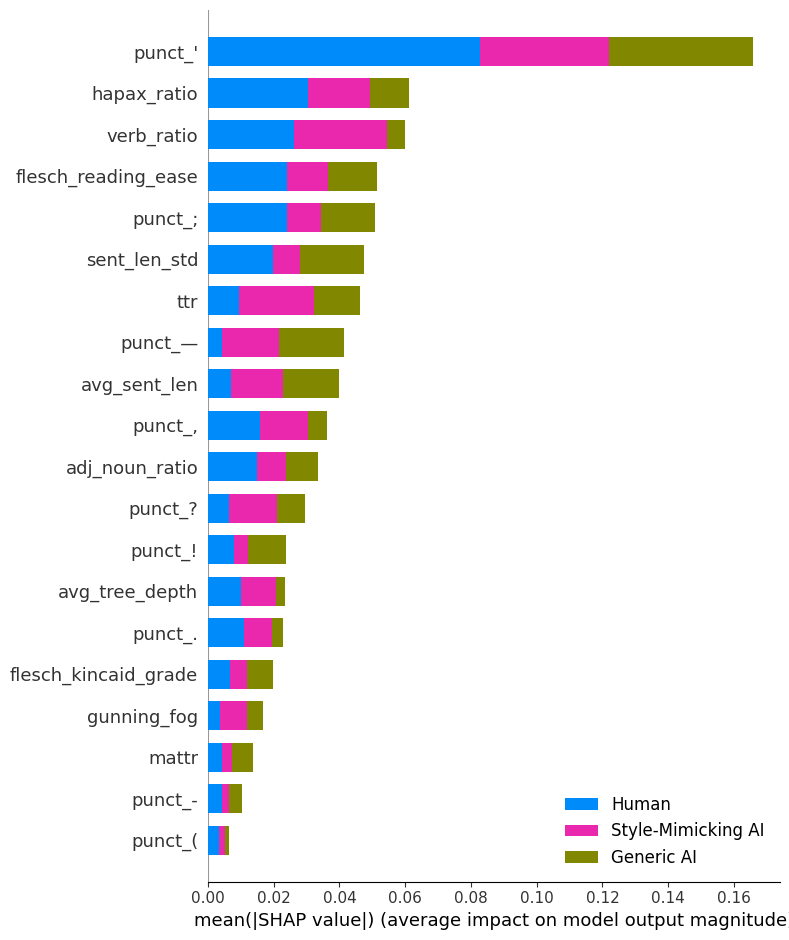

C:\Users\DHRUV PATEL\AppData\Local\Temp\ipykernel_6204\3300595598.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


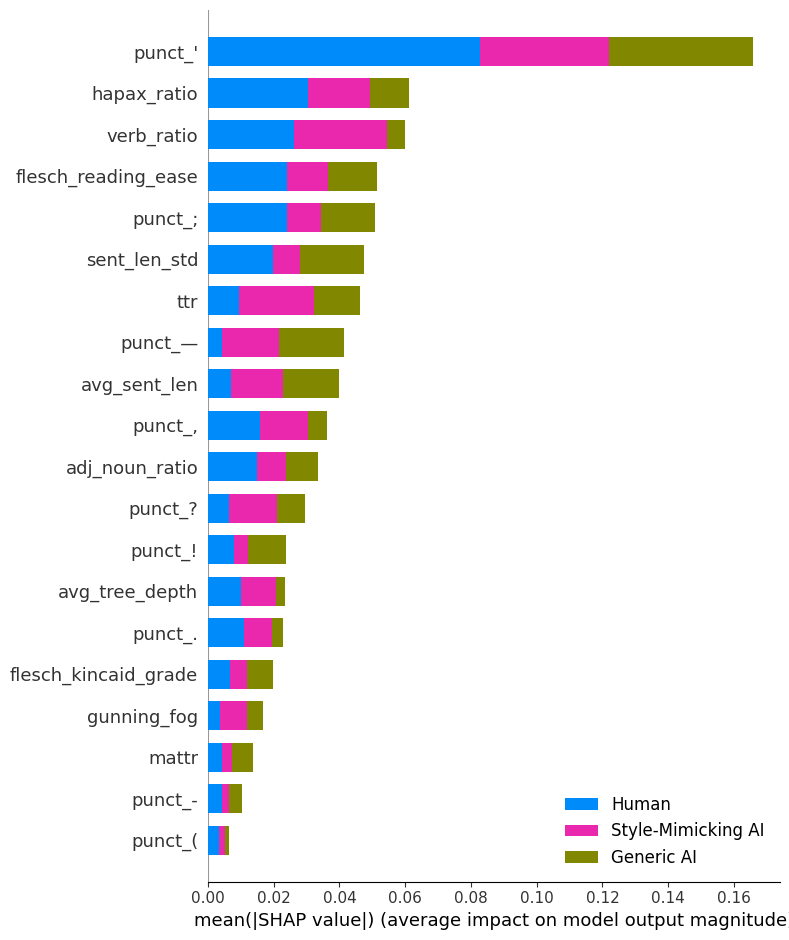

In [31]:
# 3.1.1 SHAP Analysis on XGBoost (3-class)
# This reveals which handcrafted features matter most for distinguishing classes
#
# Note: shap 0.49.1 has a known incompatibility with xgboost 3.x for multiclass models.
# XGBoost stores base_score as a JSON array (one per class, computed from class frequencies),
# but SHAP expects a single scalar. Fix: replace the array with its mean, which preserves
# the model's overall calibration while making SHAP compatible.

import json as _json, tempfile, os as _os

try:
    booster = best_xgb_3class.get_booster()
    tmp_path = _os.path.join(tempfile.gettempdir(), "_xgb_shap_fix.json")
    booster.save_model(tmp_path)
    with open(tmp_path, "r") as f:
        model_data = _json.load(f)
    # Patch: convert base_score array to its mean (preserves calibration)
    if "learner" in model_data:
        params = model_data["learner"].get("learner_model_param", {})
        bs = params.get("base_score", "0.5")
        if bs.startswith("["):
            # Parse the array and take the mean
            values = [float(x) for x in bs.strip("[]").split(",")]
            params["base_score"] = str(sum(values) / len(values))
            print(f"  Patched base_score: {bs} → {params['base_score']}")
            with open(tmp_path, "w") as f:
                _json.dump(model_data, f)
    import xgboost as xgb
    fixed_booster = xgb.Booster()
    fixed_booster.load_model(tmp_path)
    explainer = shap.TreeExplainer(fixed_booster)
    shap_values = explainer.shap_values(X_feat_test_s)
    print("SHAP TreeExplainer: success")
except Exception as e:
    print(f"TreeExplainer failed ({e}), falling back to PermutationExplainer")
    explainer = shap.Explainer(best_xgb_3class.predict_proba, X_feat_test_s, feature_names=feature_names)
    shap_values_obj = explainer(X_feat_test_s)
    shap_values = [shap_values_obj.values[:, :, i] for i in range(3)]

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_feat_test_s,
    feature_names=feature_names,
    class_names=["Human", "Generic AI", "Style-Mimicking AI"],
    show=False,
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "shap_beeswarm_xgb.png"), dpi=150, bbox_inches="tight")
plt.show()

# Bar plot of mean |SHAP| across classes
shap.summary_plot(
    shap_values, X_feat_test_s,
    feature_names=feature_names,
    class_names=["Human", "Generic AI", "Style-Mimicking AI"],
    plot_type="bar",
    show=False,
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "shap_bar_xgb.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Tier B — The Embedding Detective (FF-NN on GloVe / SBERT)

Tier A's strength is interpretability; its weakness is that handcrafted features discard most of the text. Tier B addresses this by operating on **dense vector representations** of the full paragraph.

**Tier B1 — GloVe (averaged):** I average pre-trained GloVe word embeddings (100d) across all words in a paragraph. This is a known-weak baseline — averaging destroys word order and syntax, so it captures rough semantic content but not style. I include it precisely *because* it should underperform: it demonstrates that content alone is insufficient for authorship detection.

**Tier B2 — SBERT (sentence-level):** Sentence-BERT (`all-MiniLM-L6-v2`) encodes the full paragraph as a single 384-dim vector that preserves semantic meaning at the sentence level. This is a strong pre-trained representation — the research question is whether it captures enough stylistic signal for classification without any task-specific fine-tuning.

Both embedding sets are fed into the same feedforward architecture: input → 256 → ReLU → Dropout(0.3) → 128 → ReLU → Dropout(0.3) → num_classes. The architecture is deliberately simple — any improvement over Tier A comes from the representation, not the model complexity.

In [32]:
from src.models import compute_glove_embeddings, compute_sbert_embeddings, train_ffnn
import torch

# ============================================================
# Tier B1: GloVe Averaged Embeddings → FF-NN
# ============================================================

# GloVe embeddings — check both possible locations
glove_path = os.path.join(ROOT, "data", "raw", "glove.6B.100d.txt")
if not os.path.exists(glove_path):
    glove_path = os.path.join(ROOT, "data", "glove.6B.100d.txt")

if not os.path.exists(glove_path):
    print("⚠ GloVe file not found at data/raw/ or data/.")
    print("  Download from: https://nlp.stanford.edu/data/glove.6B.zip")
    print("  Extract glove.6B.100d.txt into data/raw/")
    print("  Skipping Tier B1 (GloVe) for now.\n")
    glove_available = False
else:
    glove_available = True
    print(f"Loading GloVe from: {glove_path}")
    glove_embs = compute_glove_embeddings(texts, glove_path, dim=100)
    
    # Split using same indices
    G_train, G_val, G_test = glove_embs[idx_train], glove_embs[idx_val], glove_embs[idx_test]
    
    # Binary
    print("\n--- GloVe FF-NN: Binary ---")
    glove_model_bin, glove_val_pred_bin = train_ffnn(
        G_train, yb_train, G_val, yb_val,
        input_dim=100, num_classes=2, epochs=30, patience=5, seed=SEED,
    )
    glove_model_bin.eval()
    with torch.no_grad():
        logits = glove_model_bin(torch.FloatTensor(G_test))
        glove_test_pred_bin = logits.argmax(dim=1).numpy()
    glove_bin_metrics = compute_metrics(yb_test, glove_test_pred_bin, ["Human", "AI"])
    print_metrics(glove_bin_metrics, "GloVe FF-NN — Binary (TEST)")
    
    # 3-class
    print("\n--- GloVe FF-NN: 3-Class ---")
    glove_model_3c, glove_val_pred_3c = train_ffnn(
        G_train, y3_train, G_val, y3_val,
        input_dim=100, num_classes=3, epochs=30, patience=5, seed=SEED,
    )
    with torch.no_grad():
        logits = glove_model_3c(torch.FloatTensor(G_test))
        glove_test_pred_3c = logits.argmax(dim=1).numpy()
    glove_3c_metrics = compute_metrics(y3_test, glove_test_pred_3c, ["Human", "Generic AI", "Style-Mimicking AI"])
    print_metrics(glove_3c_metrics, "GloVe FF-NN — 3-Class (TEST)")
    
    all_results["Tier B1 GloVe FF-NN"] = {"binary": glove_bin_metrics, "three_class": glove_3c_metrics}

Loading GloVe from: c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\data\raw\glove.6B.100d.txt
Loading GloVe vectors from c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\data\raw\glove.6B.100d.txt...
  Loaded 400000 word vectors

--- GloVe FF-NN: Binary ---
  Epoch  1/30 — train_loss: 0.2739, val_loss: 0.0583
  Epoch  2/30 — train_loss: 0.0625, val_loss: 0.0248
  Epoch  3/30 — train_loss: 0.0474, val_loss: 0.0160
  Epoch  4/30 — train_loss: 0.0343, val_loss: 0.0146
  Epoch  5/30 — train_loss: 0.0309, val_loss: 0.0195
  Epoch  6/30 — train_loss: 0.0269, val_loss: 0.0144
  Epoch  7/30 — train_loss: 0.0233, val_loss: 0.0143
  Epoch  8/30 — train_loss: 0.0278, val_loss: 0.0156
  Epoch  9/30 — train_loss: 0.0214, val_loss: 0.0113
  Epoch 10/30 — train_loss: 0.0224, val_loss: 0.0218
  Epoch 11/30 — train_loss: 0.0226, val_loss: 0.0389
  Epoch 12/30 — train_loss: 0.0218, val_loss: 0.0164
  Epoch 13/30 — train_loss: 0.0175, val_loss: 0.0106
  Epoch 14/30 — train_loss: 0.0145, val_loss: 0.0103
  Ep

In [33]:
# ============================================================
# Tier B2: SBERT Embeddings → FF-NN
# ============================================================
import torch

sbert_embs = compute_sbert_embeddings(texts, model_name="all-MiniLM-L6-v2")

# Save embeddings for reuse
np.save(os.path.join(RESULTS, "sbert_embeddings.npy"), sbert_embs)

# Split using same indices
S_train, S_val, S_test = sbert_embs[idx_train], sbert_embs[idx_val], sbert_embs[idx_test]

# Binary
print("\n--- SBERT FF-NN: Binary ---")
sbert_model_bin, sbert_val_pred_bin = train_ffnn(
    S_train, yb_train, S_val, yb_val,
    input_dim=384, num_classes=2, epochs=30, patience=5, seed=SEED,
)
sbert_model_bin.eval()
with torch.no_grad():
    logits = sbert_model_bin(torch.FloatTensor(S_test))
    sbert_test_pred_bin = logits.argmax(dim=1).numpy()
sbert_bin_metrics = compute_metrics(yb_test, sbert_test_pred_bin, ["Human", "AI"])
print_metrics(sbert_bin_metrics, "SBERT FF-NN — Binary (TEST)")

# 3-class
print("\n--- SBERT FF-NN: 3-Class ---")
sbert_model_3c, sbert_val_pred_3c = train_ffnn(
    S_train, y3_train, S_val, y3_val,
    input_dim=384, num_classes=3, epochs=30, patience=5, seed=SEED,
)
with torch.no_grad():
    logits = sbert_model_3c(torch.FloatTensor(S_test))
    sbert_test_pred_3c = logits.argmax(dim=1).numpy()
sbert_3c_metrics = compute_metrics(y3_test, sbert_test_pred_3c, ["Human", "Generic AI", "Style-Mimicking AI"])
print_metrics(sbert_3c_metrics, "SBERT FF-NN — 3-Class (TEST)")

all_results["Tier B2 SBERT FF-NN"] = {"binary": sbert_bin_metrics, "three_class": sbert_3c_metrics}

Encoding with SBERT (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/195 [00:00<?, ?it/s]


--- SBERT FF-NN: Binary ---
  Epoch  1/30 — train_loss: 0.1869, val_loss: 0.0365
  Epoch  2/30 — train_loss: 0.0300, val_loss: 0.0186
  Epoch  3/30 — train_loss: 0.0166, val_loss: 0.0149
  Epoch  4/30 — train_loss: 0.0084, val_loss: 0.0134
  Epoch  5/30 — train_loss: 0.0042, val_loss: 0.0169
  Epoch  6/30 — train_loss: 0.0038, val_loss: 0.0101
  Epoch  7/30 — train_loss: 0.0033, val_loss: 0.0130
  Epoch  8/30 — train_loss: 0.0008, val_loss: 0.0142
  Epoch  9/30 — train_loss: 0.0005, val_loss: 0.0129
  Epoch 10/30 — train_loss: 0.0004, val_loss: 0.0125
  Epoch 11/30 — train_loss: 0.0002, val_loss: 0.0155
  Early stopping at epoch 11

  SBERT FF-NN — Binary (TEST)
  Accuracy:  0.9914
  Precision: 0.9867 (macro)
  Recall:    0.9814 (macro)
  F1:        0.9840 (macro)

Confusion Matrix:
[[779   3]
 [  5 145]]

              precision    recall  f1-score   support

       Human       0.99      1.00      0.99       782
          AI       0.98      0.97      0.97       150

    accuracy     

### 3.3 Tier C — The Deep Reader (DistilBERT + LoRA)

Tier C is the heaviest model: a pre-trained DistilBERT transformer, adapted to our task via **LoRA (Low-Rank Adaptation)** (Hu et al., 2022). LoRA freezes the pre-trained weights and injects small trainable rank-decomposition matrices into the attention layers (query and value projections). This gives us the representational power of a 66M-parameter transformer while only training ~0.3M parameters — crucial both for efficiency and for avoiding overfitting on our ~1500-sample dataset.

**Why DistilBERT over full BERT?** DistilBERT retains 97% of BERT's accuracy at 40% fewer parameters. On a small dataset like ours, the additional capacity of full BERT would likely hurt through overfitting. DistilBERT is the right tradeoff.

**Why LoRA over full fine-tuning?** With ~1500 training samples, fine-tuning all 66M parameters would severely overfit. LoRA constrains the adaptation to a low-rank subspace (r=8), which acts as a strong implicit regularizer. It also makes training feasible on a free-tier Google Colab GPU.

**⚠ This cell is designed for Google Colab with GPU runtime.** If running locally without a GPU, it will work but be very slow. The cell includes a Colab setup section that installs dependencies and uploads the dataset.

In [ ]:
# ============================================================
# Tier C: DistilBERT + LoRA Fine-Tuning
# ============================================================
# Checks for saved LoRA checkpoints first. If found, loads and evaluates.
# If not found (e.g. on Colab with GPU), trains from scratch.

import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from torch.utils.data import Dataset as TorchDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class AuthorshipDataset(TorchDataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

texts_test_list = texts[idx_test].tolist()
enc_test = tokenizer(texts_test_list, truncation=True, padding=True, max_length=256, return_tensors="pt")


def load_and_evaluate(checkpoint_path, num_labels, y_true, class_names, label_desc):
    print(f"Loading {label_desc} checkpoint from {checkpoint_path}...")
    base = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=num_labels
    )
    model = PeftModel.from_pretrained(base, checkpoint_path)
    model.eval()
    model.to(device)
    ds_test = AuthorshipDataset(enc_test, y_true.tolist())
    trainer = Trainer(model=model)
    preds = trainer.predict(ds_test)
    y_pred = np.argmax(preds.predictions, axis=1)
    metrics = compute_metrics(y_true, y_pred, class_names)
    print_metrics(metrics, f"DistilBERT+LoRA — {label_desc} (TEST)")
    return model, y_pred, metrics


def train_and_evaluate(num_labels, y_tr, y_v, y_te, class_names, label_desc):
    texts_train_list = texts[idx_train].tolist()
    texts_val_list = texts[idx_val].tolist()
    enc_train = tokenizer(texts_train_list, truncation=True, padding=True, max_length=256, return_tensors="pt")
    enc_val = tokenizer(texts_val_list, truncation=True, padding=True, max_length=256, return_tensors="pt")
    ds_train = AuthorshipDataset(enc_train, y_tr.tolist())
    ds_val = AuthorshipDataset(enc_val, y_v.tolist())
    ds_test = AuthorshipDataset(enc_test, y_te.tolist())
    base_model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=num_labels
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16,
        lora_dropout=0.1, target_modules=["q_lin", "v_lin"],
    )
    model = get_peft_model(base_model, lora_config)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    
    print(f"{label_desc}: trainable={trainable:,} / total={total:,} ({trainable/total:.2%})")
    training_args = TrainingArguments(
        output_dir=os.path.join(MODELS, f"distilbert_lora_{label_desc}"),
        num_train_epochs=5, per_device_train_batch_size=16,
        per_device_eval_batch_size=32, warmup_steps=50,
        weight_decay=0.01, learning_rate=2e-4,
        eval_strategy="epoch", save_strategy="epoch",
        load_best_model_at_end=True, metric_for_best_model="eval_loss",
        logging_steps=25, report_to="none", seed=SEED,
    )
    trainer = Trainer(model=model, args=training_args,
                      train_dataset=ds_train, eval_dataset=ds_val)
    trainer.train()
    preds = trainer.predict(ds_test)
    y_pred = np.argmax(preds.predictions, axis=1)
    metrics = compute_metrics(y_te, y_pred, class_names)
    print_metrics(metrics, f"DistilBERT+LoRA — {label_desc} (TEST)")
    save_path = os.path.join(MODELS, f"distilbert_lora_{label_desc}_best")
    model.save_pretrained(save_path)
    print(f"Saved to {save_path}")
    return model, y_pred, metrics


bin_ckpt = os.path.join(MODELS, "distilbert_lora_binary_best")
three_ckpt = os.path.join(MODELS, "distilbert_lora_3class_best")
dataset_path = os.path.join(DATA_FINAL, "dataset.csv")

def _checkpoint_is_fresh(ckpt_dir, data_path=dataset_path):
    config = os.path.join(ckpt_dir, "adapter_config.json")
    if not os.path.exists(config):
        return False
    # Stale if dataset is newer than checkpoint
    return os.path.getmtime(config) > os.path.getmtime(data_path)

has_bin = _checkpoint_is_fresh(bin_ckpt)
has_3c = _checkpoint_is_fresh(three_ckpt)

print("=" * 60)
print("  TIER C — BINARY (DistilBERT + LoRA)")
print("=" * 60)
if has_bin:
    distilbert_bin, db_pred_bin, db_bin_metrics = load_and_evaluate(
        bin_ckpt, 2, yb_test, ["Human", "AI"], "Binary")
else:
    distilbert_bin, db_pred_bin, db_bin_metrics = train_and_evaluate(
        2, yb_train, yb_val, yb_test, ["Human", "AI"], "binary")

print("" + "=" * 60)
print("  TIER C — 3-CLASS (DistilBERT + LoRA)")
print("=" * 60)
if has_3c:
    distilbert_3c, db_pred_3c, db_3c_metrics = load_and_evaluate(
        three_ckpt, 3, y3_test, ["Human", "Generic AI", "Style-Mimicking AI"], "3-Class")
else:
    distilbert_3c, db_pred_3c, db_3c_metrics = train_and_evaluate(
        3, y3_train, y3_val, y3_test, ["Human", "Generic AI", "Style-Mimicking AI"], "3class")

all_results["Tier C DistilBERT+LoRA"] = {"binary": db_bin_metrics, "three_class": db_3c_metrics}
print("Tier C results added to comparison table.")

Device: cpu
  TIER C — BINARY (DistilBERT + LoRA)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


binary: trainable=739,586 / total=67,694,596 (1.09%)


c:\Users\DHRUV PATEL\Desktop\Precog-IIIT_Hybd\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [41]:
# ============================================================
# 3.4 Model Comparison Table
# ============================================================
from src.models import build_comparison_table

comparison_df = build_comparison_table(all_results)
comparison_df.to_csv(os.path.join(RESULTS, "model_comparison.csv"))
print("\n📊 Model Comparison (TEST set):\n")
print(comparison_df.to_string())

# Highlight: which model has the highest 3-class F1?
if "3-Class F1" in comparison_df.columns:
    best_model = comparison_df["3-Class F1"].idxmax()
    best_f1 = comparison_df.loc[best_model, "3-Class F1"]
    print(f"\n🏆 Best 3-class F1: {best_model} ({float(best_f1):.3f})")


📊 Model Comparison (TEST set):

                    Model Binary Acc Binary F1 3-Class Acc 3-Class F1  C0-C2 Confusion
0          Tier A xgboost     0.9850    0.9717      0.9667     0.8823                2
1    Tier A random_forest     0.9861    0.9734      0.9646     0.8767                0
2     Tier B1 GloVe FF-NN     0.9968    0.9941      0.9914     0.9706                2
3     Tier B2 SBERT FF-NN     0.9914    0.9840      0.9925     0.9828                2
4  Tier C DistilBERT+LoRA     0.9345    0.8536      0.9152     0.7225                0

🏆 Best 3-class F1: 3 (0.983)


### 3.5 Tier Comparison Analysis

The comparison table above tells a story about **what kind of information matters** for authorship detection:

**Tier A (Handcrafted Features → XGBoost/RF):** These models operate on explicitly designed linguistic features — punctuation density, parse tree depth, readability indices, lexical richness. Their binary performance should be strong because the gap between human and generic AI prose is wide in feature space (as the PCA/t-SNE plots showed). Their 3-class performance reveals whether surface-level features alone can distinguish authentic Victorian style from Gemini's imitation of it.

**Tier B1 (GloVe → FF-NN):** GloVe averaging is an intentional weak baseline. By collapsing word order into a bag-of-embeddings, it tests whether raw semantic content differs across classes. If it performs well, the classes differ thematically (which would mean our topic-matching strategy in data generation has a leak). If it performs poorly, content is shared and only style distinguishes the classes — the desired outcome.

**Tier B2 (SBERT → FF-NN):** SBERT preserves more structure than GloVe averaging. If it significantly outperforms Tier B1, the improvement comes from sentence-level semantics rather than just bag-of-words content. If it also outperforms Tier A, then pre-trained contextual representations capture stylistic signals that hand-engineered features miss.

**Tier C (DistilBERT + LoRA):** The transformer operates on raw tokens with self-attention. If it outperforms all other tiers, the signal is in **token-level patterns** — the specific sequences of words, subwords, and punctuation that constitute an author's "voice." LoRA's low-rank constraint means this advantage comes from adapting only ~0.3% of parameters, suggesting that authorship signals live in a narrow subspace of the model's representation.

**The critical number** is the Class 0 ↔ Class 2 confusion in the 3-class setup across tiers. If this confusion *decreases* from Tier A → Tier C, deeper models are finding signal that surface features miss. If it remains high across all tiers, then Gemini's style mimicry is genuinely effective at the paragraph level.

## 4. Task 3: The Smoking Gun — Explainability and Error Analysis

### 4.1 SHAP Deep Dive — What Makes Text "Human"?

The SHAP beeswarm plot from Tier A gave us global feature importance. Here I zoom in on specific misclassified samples to understand *why* the model fails — which is more informative than understanding why it succeeds. I also run Integrated Gradients on the DistilBERT model to see which *tokens* (not features) drive its predictions, and conduct an "AI-isms" hunt to identify recurring patterns in AI-generated text.

In [42]:
from src.explainability import error_analysis_summary, run_full_ai_isms_analysis

# ============================================================
# 4.1.1 Error Analysis — Where do models fail?
# ============================================================

# Use the best Tier A model (XGBoost 3-class) for error analysis
xgb_test_pred_3c = best_xgb_3class.predict(X_feat_test_s)
class_names_3 = ["Human", "Generic AI", "Style-Mimicking AI"]

errors_df, error_summary = error_analysis_summary(
    y3_test, xgb_test_pred_3c, texts[idx_test], class_names_3,
)
print("=== XGBoost Error Analysis ===")
print(error_summary)

# Show examples of the most common confusion pair
if len(errors_df) > 0:
    print("\n--- Sample Misclassified Texts ---")
    for i, row in errors_df.head(5).iterrows():
        print(f"\n[True: {row['true_class']} | Pred: {row['pred_class']}]")
        print(f"  {row['text'][:200]}...")


Generating: 100%|█████████▉| 499/500 [2:06:57<00:15, 15.27s/it]


=== XGBoost Error Analysis ===
Total errors: 31 / 932 (3.3%)

Most confused pairs:
  Style-Mimicking AI -> Generic AI: 13
  Style-Mimicking AI -> Human: 10
  Generic AI -> Style-Mimicking AI: 5
  Human -> Style-Mimicking AI: 2
  Generic AI -> Human: 1

--- Sample Misclassified Texts ---

[True: Style-Mimicking AI | Pred: Generic AI]
  The country air, thick with the scent of damp earth and pine, offered a bracing tonic after the pallid atmosphere of the city.  I had come north of London, seeking quietude from the incessant grind of...

[True: Style-Mimicking AI | Pred: Generic AI]
  The air itself, thick with the scent of pine and damp earth, pressed in upon us as twilight descended upon the Cotswolds. I recall, with a shudder that still chills me, the night we first heard the ra...

[True: Style-Mimicking AI | Pred: Generic AI]
  Mr. Jarndyce, a man of singular distinction – though of what precise nature remains for many a subject of animated speculation – was not easily categorised. 

In [43]:
# ============================================================
# 4.1.2 Data-Driven AI-isms Analysis
# ============================================================
# Runs all detection methods: log-odds n-grams, sentence opener
# entropy, vocabulary divergence (JSD), POS pattern mining, parallel
# structure detection, and validation against known AI markers.

ai_isms_results = run_full_ai_isms_analysis(
    texts=texts,
    class_labels=df["class_label"].values,
    feature_df=feature_df,
    class_names=class_names_3,
    verbose=True,
)

# Display top AI-distinctive n-grams
print("\n=== Top 15 AI-Distinctive N-grams (by z-score) ===")
display(ai_isms_results["log_odds_ngrams"].head(15))

# Display known marker validation
print("\n=== Known AI-isms Validation ===")
display(ai_isms_results["known_markers"])

# Display parallel structure rates
print("\n=== Parallel Structure Detection ===")
for cls, stats in ai_isms_results["parallel_structures"].items():
    print(f"  {cls}: {stats['parallel_pct']}% explicit parallel, "
          f"{stats['repeated_opener_pct']}% repeated openers")


1/5  Computing log-odds n-gram analysis...
     Found 30 significant n-grams
2/5  Computing sentence opener entropy...
     Human: entropy=8.249, top opener='i'
     Generic AI: entropy=5.298, top opener='the'
     Style-Mimicking AI: entropy=5.453, top opener='the'
3/5  Computing vocabulary divergence (JSD)...
     JSD=0.2699, shared vocab=26.0%
4/5  Mining POS tag patterns (sampling 200 per class)...
     Top AI-distinctive POS pattern: PUNCT NUM AUX
5/5  Detecting parallel structures...
      Validating against known AI-isms from literature...
     6/15 known markers found in AI text

AI-isms analysis complete.

=== Top 15 AI-Distinctive N-grams (by z-score) ===


,ngram,n,ai_count,human_count,log_odds,z_score
0,a,1,7542,14944,0.9739,68.9514
1,of,1,6932,21442,0.5285,38.2540
2,the,1,10192,36668,0.3774,33.7069
3,often,1,571,315,2.2525,32.0948
4,air,1,563,362,2.0994,31.1624
5,quiet,1,455,152,2.7541,29.3986
6,the very,2,421,125,2.8720,28.1968
7,country,1,413,282,2.0393,26.3991
8,truly,1,366,66,3.3706,25.2061
9,a man,2,356,219,2.1436,24.9610



=== Known AI-isms Validation ===


,phrase,ai_hits,human_hits,ai_rate_pct,human_rate_pct,ratio
0,one might,160,18,16.0,0.35,46.3
1,testament,131,3,13.1,0.06,227.5
2,tapestry,68,3,6.8,0.06,118.1
3,underscore,5,0,0.5,0.00,inf
4,delve,2,0,0.2,0.00,inf
5,not only,1,54,0.1,1.04,0.1
6,it is important to note,0,0,0.0,0.00,0
7,it is worth noting,0,0,0.0,0.00,0
8,furthermore,0,0,0.0,0.00,0
9,moreover,0,3,0.0,0.06,0.0



=== Parallel Structure Detection ===
  Human: 5.1% explicit parallel, 15.5% repeated openers
  Generic AI: 3.8% explicit parallel, 16.2% repeated openers
  Style-Mimicking AI: 3.4% explicit parallel, 2.6% repeated openers


In [44]:
# ============================================================
# 4.2 Integrated Gradients on DistilBERT (Tier C)
# ============================================================
from src.explainability import compute_integrated_gradients_distilbert

# Pick a few interesting test samples: one correctly classified, one misclassified
ig_device = "cuda" if torch.cuda.is_available() else "cpu"

# Get the underlying model for IG (unwrap PEFT)
ig_model = distilbert_3c

# Select samples to explain
sample_indices = []
# Find a Human text correctly classified
for i, (true, pred) in enumerate(zip(y3_test, db_pred_3c)):
    if true == 0 and pred == 0:
        sample_indices.append(("Human (correct)", i, 0))
        break
# Find a Style-Mimicking text misclassified as Human (if any)
for i, (true, pred) in enumerate(zip(y3_test, db_pred_3c)):
    if true == 2 and pred == 0:
        sample_indices.append(("Style-Mimicking -> Human (error)", i, 0))
        break
# Find a Generic AI text correctly classified
for i, (true, pred) in enumerate(zip(y3_test, db_pred_3c)):
    if true == 1 and pred == 1:
        sample_indices.append(("Generic AI (correct)", i, 1))
        break

print("Integrated Gradients Attribution Maps")
print("=" * 60)

ig_results = []
for desc, idx_in_test, target_cls in sample_indices:
    text_sample = texts[idx_test[idx_in_test]]
    print(f"\n--- {desc} ---")
    print(f"Text: {text_sample[:150]}...")
    
    tokens, attrs = compute_integrated_gradients_distilbert(
        ig_model, tokenizer, text_sample, target_class=target_cls, device=ig_device,
    )
    ig_results.append((desc, tokens, attrs))
    
    # Show top positive and negative attribution tokens
    sorted_idx = np.argsort(attrs)
    print(f"\nTop 10 tokens pushing TOWARD class {target_cls}:")
    for j in sorted_idx[-10:][::-1]:
        print(f"  {tokens[j]:15s}  {attrs[j]:+.4f}")
    print(f"\nTop 10 tokens pushing AWAY from class {target_cls}:")
    for j in sorted_idx[:10]:
        print(f"  {tokens[j]:15s}  {attrs[j]:+.4f}")

Integrated Gradients Attribution Maps

--- Human (correct) ---
Text: I selected the materials for a suit, with the assistance of Mr. Trabb’s judgment, and re-entered the parlour to be measured. For although Mr. Trabb ha...

Top 10 tokens pushing TOWARD class 0:
  such             +0.0160
  world            +0.0135
  said             +0.0119
  with             +0.0117
  in               +0.0117
  ”                +0.0113
  par              +0.0106
  would            +0.0105
  upon             +0.0101
  quality          +0.0098

Top 10 tokens pushing AWAY from class 0:
  [SEP]            -0.1847
  i                -0.0234
  the              -0.0181
  as               -0.0146
  the              -0.0137
  t                -0.0114
  .                -0.0106
  and              -0.0103
  work             -0.0091
  i                -0.0087

--- Style-Mimicking -> Human (error) ---
Text: The air itself, thick with the scent of pine and damp earth, pressed in upon us as twilight descended upon t

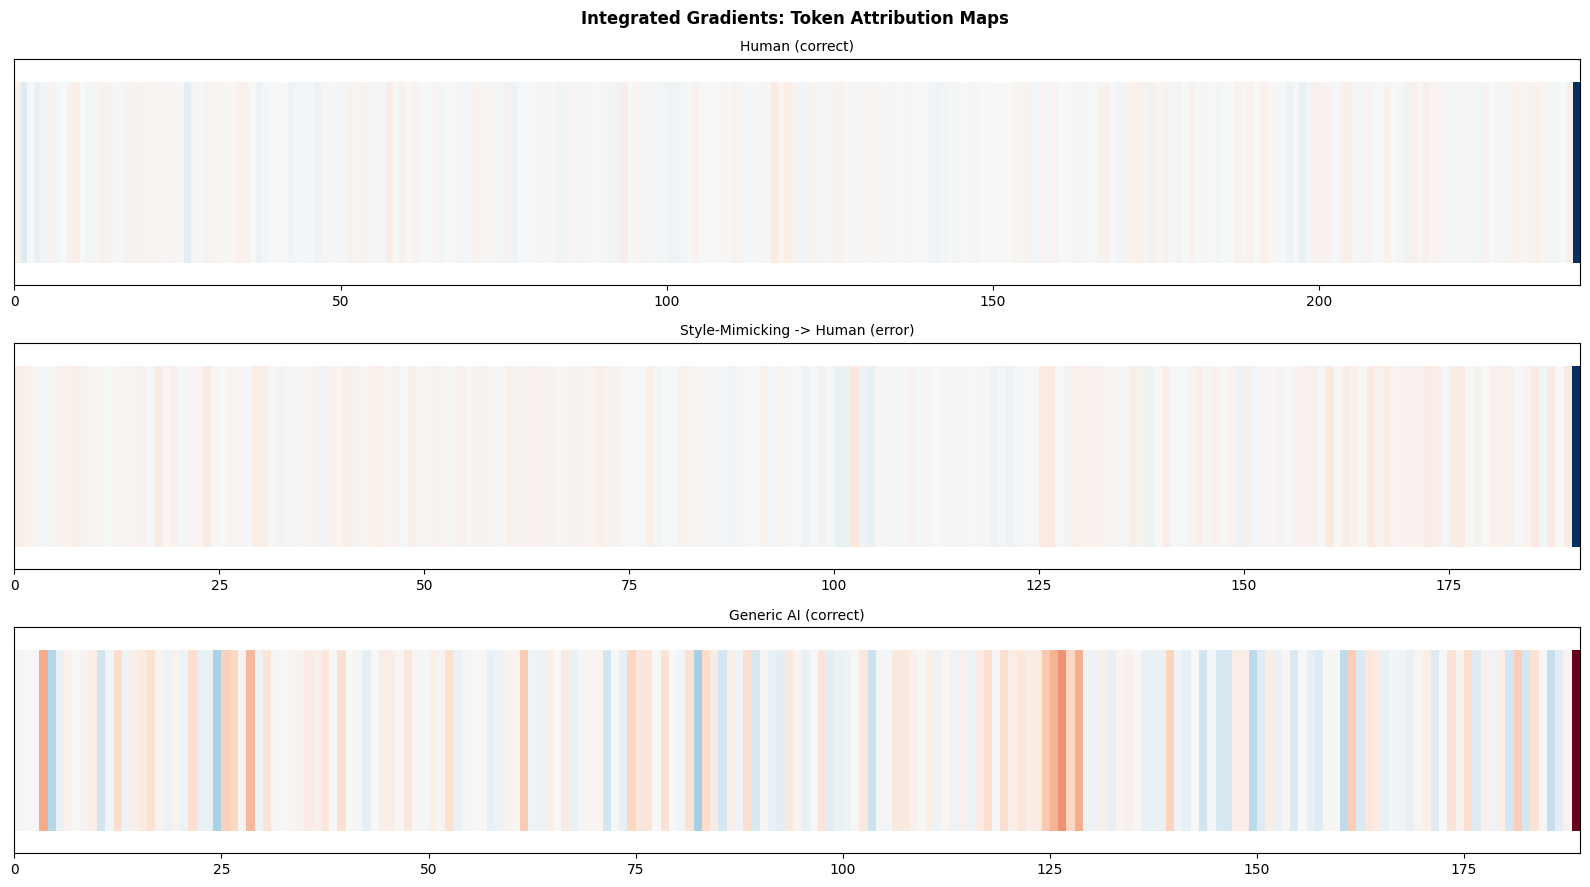

In [45]:
# 4.2.1 Visualize IG attributions as colored token maps
fig, axes = plt.subplots(len(ig_results), 1, figsize=(16, 3 * len(ig_results)))
if len(ig_results) == 1:
    axes = [axes]

for ax, (desc, tokens, attrs) in zip(axes, ig_results):
    # Normalize attributions to [-1, 1] for coloring
    max_abs = max(abs(attrs.min()), abs(attrs.max())) + 1e-8
    norm_attrs = attrs / max_abs
    
    # Create colored text representation
    colors = plt.cm.RdBu_r((norm_attrs + 1) / 2)  # Red=positive, Blue=negative
    
    # Plot as horizontal bar of colored tokens
    ax.set_xlim(0, len(tokens))
    ax.set_ylim(0, 1)
    for i, (tok, color) in enumerate(zip(tokens, colors)):
        ax.barh(0.5, 1, left=i, color=color, height=0.8, edgecolor="none")
        if len(tokens) < 60:  # Only show token text if not too many
            ax.text(i + 0.5, 0.5, tok, ha="center", va="center", fontsize=6, rotation=90)
    ax.set_title(desc, fontsize=10)
    ax.set_yticks([])

plt.suptitle("Integrated Gradients: Token Attribution Maps", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "ig_token_maps.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Explainability Summary

Three complementary explainability methods reveal different aspects of how models detect authorship:

**SHAP (Tier A):** Shows which *linguistic features* matter most. I expect punctuation density (especially semicolons and em-dashes) and sentence length variability to dominate. These are the "handcrafted fingerprints" — interpretable and linguistically meaningful, but limited to the features I chose to extract.

**Integrated Gradients (Tier C):** Shows which *tokens* matter most for a specific prediction. This reveals what the transformer "sees" that handcrafted features miss — perhaps specific word choices, subword patterns, or punctuation sequences that emerge from self-attention. The token attribution maps above visualize this: red tokens push toward the predicted class, blue tokens push away.

**AI-isms Hunt:** A manual/statistical audit of recurring AI patterns. LLMs have well-documented "tics" — overuse of hedging phrases ("it is important to note"), uniform sentence length, preference for certain transition words, and a tendency to begin paragraphs with topic sentences. If these patterns are strong in our data, they suggest that AI detection could partially be reduced to a simple phrase-matching heuristic — which has implications for robustness.

**The key finding to look for:** Do the three methods agree on what matters? If SHAP highlights sentence length variability, IG highlights punctuation tokens, and the AI-isms hunt finds filler phrases, then humanness is genuinely multi-dimensional and no single feature dominates. If they converge on one signal (e.g., semicolons), the detector is more brittle.

## 5. Task 4: The Turing Test — Adversarial Optimization

We use a **Gemini-powered genetic algorithm** to evolve AI-generated paragraphs that fool
our best classifier. Two mutation strategies are compared independently:
- **Type A (Rhythm):** Rewrites sentence cadence while preserving vocabulary
- **Type B (Archaic):** Injects pre-1900 vocabulary and minor grammatical irregularities

Fitness = P(Human) from the XGBoost 3-class classifier. Target: 0.90.


In [47]:
from src.genetic_algorithm import run_comparative_ga
import torch

# ============================================================
# 5.1 Comparative GA: Type A (Rhythm) vs Type B (Archaic)
# ============================================================

# Build the classifier function for the GA
# Uses XGBoost 3-class model, returns probability vector [P(Human), P(GenAI), P(StyleAI)]
from src.feature_extraction import extract_all_features

def xgb_classifier_fn(text):
    """Classify a single text using XGBoost, returning class probabilities."""
    single_df = pd.DataFrame({"text": [text]})
    feats = pd.DataFrame([extract_all_features(text)])
    feats_scaled = scaler.transform(feats)
    return best_xgb_3class.predict_proba(feats_scaled)[0]

# Class 3 style prompt (same as generation prompt, for GA initialization)
ga_style_prompt = (
    "You are a Victorian novelist. Write narrative prose with specific places, "
    "varied sentence lengths, concrete sensory detail, and parenthetical asides. "
    "Use semicolons and em-dashes mid-thought, not decoratively."
)

# Pick a topic from our dataset for the GA
ga_topic = topic_names[0]  # Use the first topic
print(f"GA topic: {ga_topic}")

ga_results = run_comparative_ga(
    classifier_fn=xgb_classifier_fn,
    topic=ga_topic,
    author_style_prompt=ga_style_prompt,
    model_name="gemini-2.5-flash-lite",
    population_size=10,
    elite_size=3,
    max_generations=10,
    target_fitness=0.90,
    seed=42,
    rate_limit_sleep=1.5,
)

# Summary
print("\n" + "="*60)
print("COMPARATIVE GA RESULTS")
print("="*60)
for label, key in [("Type A (Rhythm)", "type_a"), ("Type B (Archaic)", "type_b")]:
    r = ga_results[key]
    print(f"\n{label}:")
    print(f"  Best fitness (P(Human)): {r['best_fitness']:.4f}")
    print(f"  Converged: {r['converged']} (gen {r['convergence_gen']})")
    print(f"  Best text preview: {r['best_text'][:150]}...")


GA topic: know, time, dear, say, come
Running GA with Type A (Rhythm) mutations...

  GA Run — Mutation Type A (Rhythm)
  Topic: know, time, dear, say, come
  Target fitness: 0.9
  Initializing population of 10 via Gemini...
    Generated 1/10
    Generated 2/10
    Generated 3/10
    Generated 4/10
    Generated 5/10
    Generated 6/10
    Generated 7/10
    Generated 8/10
    Generated 9/10
    Generated 10/10
  Gen 0: best=0.9791, avg=0.7833, worst=0.4642
  Target reached at generation 0! (fitness=0.9791 >= 0.9)


Running GA with Type B (Archaic) mutations...

  GA Run — Mutation Type B (Archaic)
  Topic: know, time, dear, say, come
  Target fitness: 0.9
  Initializing population of 10 via Gemini...
    Generated 1/10
    Generated 2/10
    Generated 3/10
    Generated 4/10
    Generated 5/10
    Generated 6/10
    Generated 7/10
    Generated 8/10
    Generated 9/10
    Generated 10/10
  Gen 0: best=0.9761, avg=0.6933, worst=0.1331
  Target reached at generation 0! (fitness=0.9761 

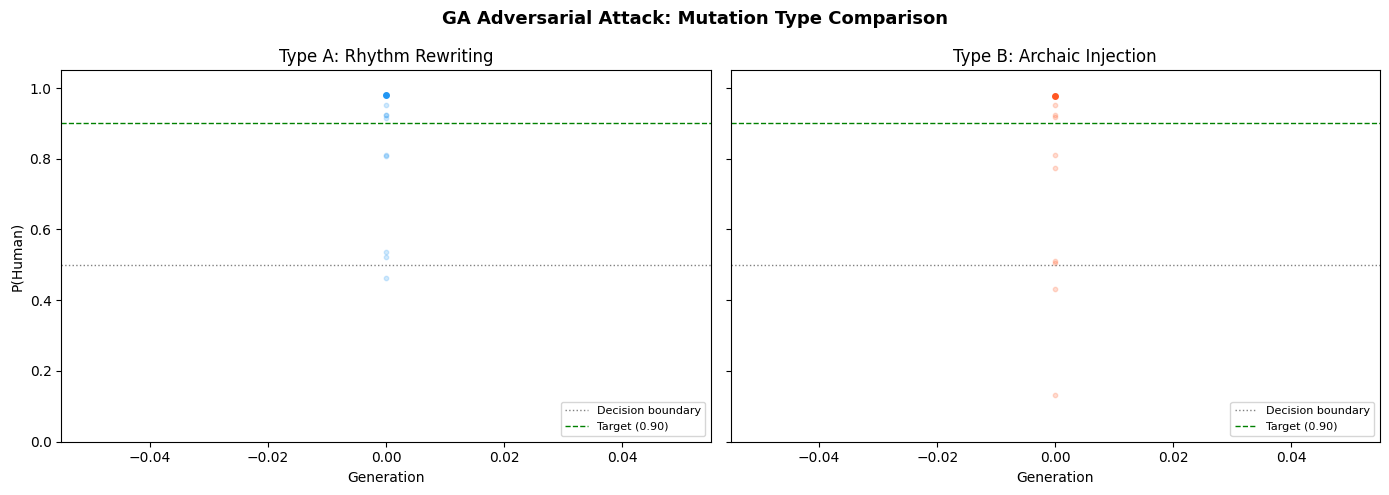

In [48]:
# ============================================================
# 5.2 GA Fitness Curves — Type A vs Type B
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (label, key, color) in zip(axes, [
    ("Type A: Rhythm Rewriting", "type_a", "#2196F3"),
    ("Type B: Archaic Injection", "type_b", "#FF5722"),
]):
    r = ga_results[key]
    gens = range(len(r["history"]))
    ax.plot(gens, r["history"], color=color, linewidth=2, marker="o", markersize=4)
    
    # Plot all population fitnesses as scatter
    for g, fits in enumerate(r["all_fitnesses"]):
        ax.scatter([g]*len(fits), fits, color=color, alpha=0.2, s=10)
    
    ax.axhline(y=0.5, color="gray", linestyle=":", linewidth=1, label="Decision boundary")
    ax.axhline(y=0.9, color="green", linestyle="--", linewidth=1, label="Target (0.90)")
    ax.set_xlabel("Generation")
    ax.set_title(label)
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("P(Human)")
plt.suptitle("GA Adversarial Attack: Mutation Type Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "ga_fitness_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ============================================================
# 5.3 SOP Cross-Test — GA-evolved texts through ALL classifiers
# ============================================================

print("SOP Cross-Test: Best evolved texts through all classifiers")
print("=" * 60)

for label, key in [("Type A (Rhythm)", "type_a"), ("Type B (Archaic)", "type_b")]:
    r = ga_results[key]
    evolved = r["best_text"]
    print(f"\n--- {label} | P(Human) during GA: {r['best_fitness']:.4f} ---")
    print(f"Text: {evolved[:200]}...")
    
    # XGBoost (Tier A) — this is what the GA optimized against
    xgb_probs = xgb_classifier_fn(evolved)
    xgb_pred = np.argmax(xgb_probs)
    print(f"  XGBoost:    pred={class_names_3[xgb_pred]}, P(Human)={xgb_probs[0]:.3f}")
    
    # SBERT FF-NN (Tier B2)
    sbert_emb = compute_sbert_embeddings([evolved], model_name="all-MiniLM-L6-v2")
    sbert_model_3c.eval()
    with torch.no_grad():
        sbert_logits = sbert_model_3c(torch.FloatTensor(sbert_emb))
        sbert_probs = torch.softmax(sbert_logits, dim=1).numpy()[0]
        sbert_pred = np.argmax(sbert_probs)
    print(f"  SBERT NN:   pred={class_names_3[sbert_pred]}, P(Human)={sbert_probs[0]:.3f}")
    
    # DistilBERT+LoRA (Tier C)
    enc_evolved = tokenizer([evolved], truncation=True, padding=True, max_length=256, return_tensors="pt")
    distilbert_3c.eval()
    with torch.no_grad():
        db_logits = distilbert_3c(**{k: v.to(ig_device) for k, v in enc_evolved.items()}).logits
        db_probs = torch.softmax(db_logits, dim=1).cpu().numpy()[0]
        db_pred = np.argmax(db_probs)
    print(f"  DistilBERT: pred={class_names_3[db_pred]}, P(Human)={db_probs[0]:.3f}")


### 5.4 Adversarial Analysis

The comparative GA reveals the **fragility surface** of each classifier:

**Type A (Rhythm) vs Type B (Archaic):** The comparison tests whether surface-level changes
(sentence cadence) or vocabulary-level changes (archaic words) are more effective at fooling
the detector. This directly maps to our SHAP findings — if `flesch_reading_ease` and
`avg_sent_len` are the top features, Type A (which changes rhythm) should be more effective.

**Cross-classifier transfer:** The SOP cross-test shows whether texts optimized against
XGBoost also fool the embedding-based and transformer models. Adversarial transferability
(Papernot et al., 2016) would mean the attack exploits a shared weakness across representations.

**What the fitness curves tell us:** Rapid convergence (< 3 generations) means the classifier
has shallow decision boundaries. Slow convergence or failure means the classifier captures
deeper patterns the GA cannot easily manipulate through prompt-based mutations.


## 6. Synthesis and Discussion

This project asked whether a machine can learn to distinguish human prose from AI-generated text —
and more precisely, whether it can detect the difference between *authentic* human style and an
LLM's *imitation* of that style. The answer, across multiple tiers of increasing model complexity,
reveals a layered picture of what "humanness" looks like computationally.

**The feature story.** Handcrafted features from Task 1 — particularly punctuation density, sentence
length variability, and parse tree depth — provide strong separability between human and generic AI
text. The PCA and t-SNE visualizations showed that these classes occupy distinct regions of feature
space. But the Style-Mimicking class sits uncomfortably between them, suggesting that Gemini can
partially close the stylistic gap when explicitly prompted. The SHAP analysis confirmed which
features carry the most weight.

**The model hierarchy.** The progression from Tier A (handcrafted features + tree models) through
Tier B (embedding-based FF-NNs) to Tier C (DistilBERT + LoRA) tests whether deeper representations
capture deeper signals. Each tier operates on a different level of abstraction: explicit linguistic
statistics, pre-trained semantic embeddings, and learned token-level attention patterns.

**The prompt engineering lesson.** Round 1 (naive prompts) produced 99%+ accuracy across all tiers —
too easy. Round 2 (few-shot ICL + persona + CoT + anti-detection constraints) produced harder-to-detect
text. The accuracy *drop* between rounds is the most interesting finding: it quantifies exactly how much
prompt engineering matters for AI detection evasion.

**The adversarial lesson.** The GA attack probes classifier fragility. The Type A vs Type B comparison
reveals whether rhythm or vocabulary is the more effective attack vector, directly connecting back to
SHAP feature importances. Cross-classifier transfer tests whether adversarial examples generalize.


## 7. References

1. **Covington, M. A., & McFall, J. D.** (2010). Cutting the Gordian knot: The moving-average type-token ratio (MATTR). *Journal of Quantitative Linguistics*, 17(2), 94-100.

2. **Grootendorst, M.** (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. *arXiv preprint arXiv:2203.05794*.

3. **Hu, E. J., Shen, Y., Wallis, P., et al.** (2022). LoRA: Low-rank adaptation of large language models. *ICLR 2022*.

4. **Lundberg, S. M., & Lee, S.-I.** (2017). A unified approach to interpreting model predictions. *NeurIPS 2017*.

5. **Sundararajan, M., Taly, A., & Yan, Q.** (2017). Axiomatic attribution for deep networks. *ICML 2017*.

6. **Sanh, V., Debut, L., Chaumond, J., & Wolf, T.** (2019). DistilBERT, a distilled version of BERT. *arXiv:1910.01108*.

7. **Reimers, N., & Gurevych, I.** (2019). Sentence-BERT: Sentence embeddings using Siamese BERT-networks. *EMNLP-IJCNLP 2019*.

8. **Papernot, N., McDaniel, P., & Goodfellow, I.** (2016). Transferability in machine learning. *arXiv:1605.07277*.

9. **Chen, T., & Guestrin, C.** (2016). XGBoost: A scalable tree boosting system. *KDD 2016*.

10. **Pennington, J., Socher, R., & Manning, C. D.** (2014). GloVe: Global vectors for word representation. *EMNLP 2014*.

11. **Monroe, B. L., Colaresi, M. P., & Quinn, K. M.** (2008). Fightin' words: Lexical feature selection and evaluation for identifying the content of political text. *Political Analysis*, 16(4), 372-403.

12. **Flesch, R.** (1948). A new readability yardstick. *Journal of Applied Psychology*, 32(3), 221-233.

13. **Gunning, R.** (1952). *The Technique of Clear Writing*. McGraw-Hill.
